In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import blurtool

import torch
from PIL import Image

import matplotlib.pyplot as plt
import torchvision
import math
import random

# Nonstationary blur modeling using robust eigenkernels

Abstract: 

### Example 0
figure showing LSV convolution, approximate LSV filter and PCA eigenkernel forward method.

img_shape= torch.Size([256, 256])
kernel_shape= (32, 32)
sampled_shape= (8, 8)
finished row  0
finished row  1
finished row  2
finished row  3
finished row  4
finished row  5
finished row  6
finished row  7
finished row  8
finished row  9
finished row  10
finished row  11
finished row  12
finished row  13
finished row  14
finished row  15
finished row  16
finished row  17
finished row  18
finished row  19
finished row  20
finished row  21
finished row  22
finished row  23
finished row  24
finished row  25
finished row  26
finished row  27
finished row  28
finished row  29
finished row  30
finished row  31
finished row  32
finished row  33
finished row  34
finished row  35
finished row  36
finished row  37
finished row  38
finished row  39
finished row  40
finished row  41
finished row  42
finished row  43
finished row  44
finished row  45
finished row  46
finished row  47
finished row  48
finished row  49
finished row  50
finished row  51
finished row  52
finished row  53
finished row 

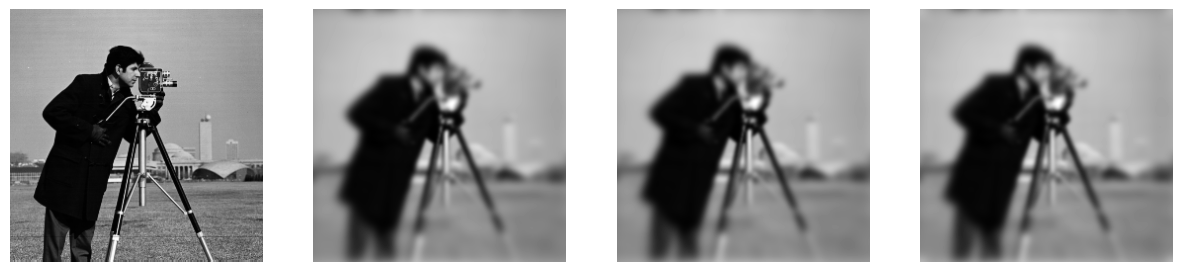

-------------------------------------------------------
forward_timer_lsvc= 14133.583396951028
forward_timer_approxfilter= 330.4767268980504
forward_timer_pca= 0.045063849014695734
-------------------------------------------------------
PSNR(blurred_lsvc,blurred_approxfilter)= tensor(30.4990, dtype=torch.float64)
PSNR(blurred_approxfilter,blurred_pca)= tensor(40.6253, dtype=torch.float64)
PSNR(blurred_lsvc,blurred_pca)= tensor(30.7914, dtype=torch.float64)
-------------------------------------------------------
SSIM(blurred_lsvc,blurred_approxfilter)= tensor(0.9811, dtype=torch.float64)
SSIM(blurred_approxfilter,blurred_pca)= tensor(0.9987, dtype=torch.float64)
SSIM(blurred_lsvc,blurred_pca)= tensor(0.9821, dtype=torch.float64)


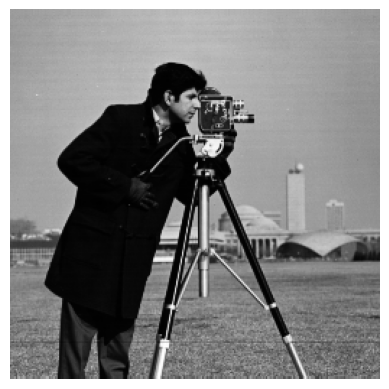

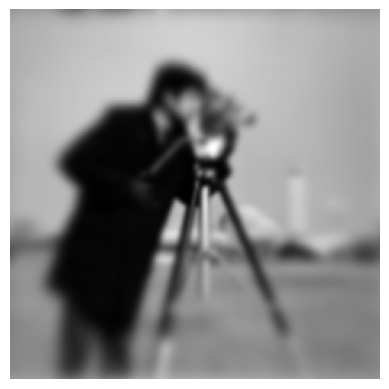

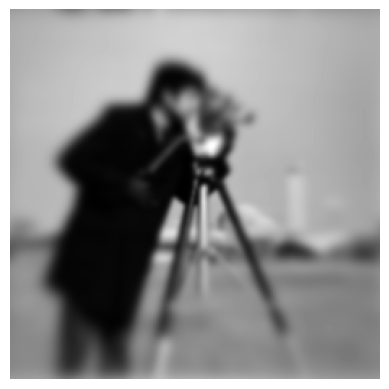

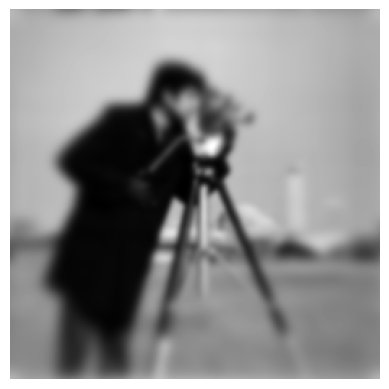

In [301]:
# test approx=False in nonstationary blur with a nondecomposed lattice (parallel forward)

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
img_shape=test_image.shape
print('img_shape=',img_shape)

# define lattice
kernel_shape=(32,32)
lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1} # 0.07
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)
print('sampled_shape=',sampled_shape)
r=15
pars_pca={'r':r}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)

# lsvc blur
rgblur_lsvc=blurtool.NonstationaryBlur(lat,approx=False)
blurred_test_image_lsvc=rgblur_lsvc.forward(test_image,n_pool=8,debug=True)
print('computed lsvc blurred image')

# approx filter blur
rgblur=blurtool.NonstationaryBlur(lat)
blurred_test_image=rgblur.forward(test_image,n_pool=8)
print('computed approx filter blurred image')

# pca lat blur 
pca_blur=blurtool.NonstationaryBlur(pca_lat)
blurred_test_image_pca=pca_blur.forward(test_image)
print('computed pca lat blurred image')

# # results
fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_lsvc,cmap='gray')
ax[2].axis('off')
ax[2].imshow(blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(blurred_test_image_pca,cmap='gray')
plt.show()

print('-------------------------------------------------------')
print('forward_timer_lsvc=',rgblur_lsvc.forward_timer)
print('forward_timer_approxfilter=',rgblur.forward_timer)
print('forward_timer_pca=',pca_blur.forward_timer)
print('-------------------------------------------------------')
print('PSNR(blurred_lsvc,blurred_approxfilter)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image))
print('PSNR(blurred_approxfilter,blurred_pca)=',blurtool.psnr(blurred_test_image,blurred_test_image_pca))
print('PSNR(blurred_lsvc,blurred_pca)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image_pca))
print('-------------------------------------------------------')
print('SSIM(blurred_lsvc,blurred_approxfilter)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image))
print('SSIM(blurred_approxfilter,blurred_pca)=',blurtool.ssim(blurred_test_image,blurred_test_image_pca))
print('SSIM(blurred_lsvc,blurred_pca)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image_pca))

# save images
plt.imshow(test_image,cmap='gray')
plt.axis('off')
plt.savefig('ex0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image_lsvc,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_lvsc.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_approxfilter.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image_pca,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

## Numerical experiments

### Example 1 (salt and pepper corrupted PSF)

In [3]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
# test_image=Image.open('../../data/ccia/47.gif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze().double()

# resize and normalize
test_image=resize(test_image.unsqueeze(0)).squeeze()
test_image=blurtool.normalize_minmax(test_image)
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(32,32)
lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)

# # find out the greatest salt and lowest pepper values
# salt_val=-10000
# pepper_val=10000
# for key in sampled_lat.kernels:
#     if torch.max(sampled_lat.kernels[key].psf_data)>salt_val:
#         salt_val=torch.max(sampled_lat.kernels[key].psf_data)
#     if torch.min(sampled_lat.kernels[key].psf_data)<pepper_val:
#         pepper_val=torch.min(sampled_lat.kernels[key].psf_data)

# use individual salt and pepper values
salt_val=None
pepper_val=None

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat.kernels:
    sampled_lat.kernels[key].psf_data=blurtool.spnoise(sampled_lat.kernels[key].psf_data,amount=0.1,salt_val=salt_val,pepper_val=pepper_val) # 0.1 # 0.2
 

img_shape= torch.Size([256, 256])
kernel_shape= (32, 32)


/home/mauro/miniconda3/envs/blurtool/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


In [5]:
# find amplitude of maximum values
wlamb_unraveled=torch.zeros(sampled_shape)
max_sampled_kernels_unraveled=[]
for key in sampled_lat.kernels:
    #print(torch.round(torch.max(sampled_lat.kernels[key].psf_data),decimals=3).item())
    max_sampled_kernels_unraveled.append(torch.max(sampled_lat.kernels[key].psf_data).item())

amplitude_lamb=max(max_sampled_kernels_unraveled)
print(amplitude_lamb)

0.04986076043330881


[0.04500000178813934, 0.04600000008940697, 0.04699999839067459, 0.04800000041723251, 0.04800000041723251, 0.04699999839067459, 0.04600000008940697, 0.04500000178813934, 0.04600000008940697, 0.04800000041723251, 0.05000000074505806, 0.05299999937415123, 0.05299999937415123, 0.050999999046325684, 0.04800000041723251, 0.04600000008940697, 0.04699999839067459, 0.05000000074505806, 0.0560000017285347, 0.06199999898672104, 0.06300000101327896, 0.0560000017285347, 0.050999999046325684, 0.04699999839067459, 0.04800000041723251, 0.05299999937415123, 0.06199999898672104, 0.0860000029206276, 0.08799999952316284, 0.06300000101327896, 0.05299999937415123, 0.04800000041723251, 0.04800000041723251, 0.05299999937415123, 0.06300000101327896, 0.08799999952316284, 0.09000000357627869, 0.06400000303983688, 0.05299999937415123, 0.04800000041723251, 0.04699999839067459, 0.050999999046325684, 0.0560000017285347, 0.06300000101327896, 0.06400000303983688, 0.05700000002980232, 0.050999999046325684, 0.0469999983

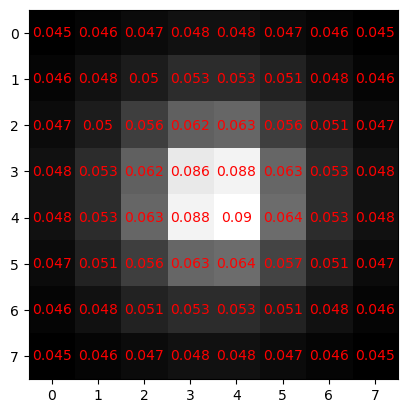

In [6]:
# sampled_shape=(8,8)
# psf_pars={'sx':0.8,'sy':0.8}
# wlamb_unraveled=blurtool.Kernel(sampled_shape,mode='gaussian',psf_pars=psf_pars)()
# wlamb_unraveled=wlamb_unraveled-torch.min(wlamb_unraveled)
# # wlamb_unraveled=0.03+2.8*wlamb_unraveled
# wlamb_unraveled=0.015+4.5*wlamb_unraveled 
# wlamb_unraveled=torch.round(wlamb_unraveled,decimals=3)


# find amplitude of maximum values
wlamb_unraveled=torch.zeros(sampled_shape)
max_sampled_kernels_unraveled=[]
for key in sampled_lat.kernels:
    #print(torch.round(torch.max(sampled_lat.kernels[key].psf_data),decimals=3).item())
    max_sampled_kernels_unraveled.append(torch.max(sampled_lat.kernels[key].psf_data).item())

amplitude_lamb=max(max_sampled_kernels_unraveled)

for key in sampled_lat.kernels:
    wlamb_unraveled[key[0],key[1]]=torch.max(sampled_lat.kernels[key].psf_data)+(0.09-amplitude_lamb)
    wlamb_unraveled[key[0],key[1]]=torch.round(wlamb_unraveled[key[0],key[1]],decimals=3)
    

# visualize wlamb_unraveled
fig, ax = plt.subplots()
ax.imshow(wlamb_unraveled,cmap='gray')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax.text(j, i, str(wlamb_unraveled.clone().detach().numpy()[i, j]), color='r', ha='center', va='center')

        
# write raveled wlamb
wlamb=[None for i in range(sampled_shape[0]*sampled_shape[1])]
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        raveled_pos=blurtool.ravel_multi_index((i,j),sampled_shape)
        wlamb[raveled_pos]=wlamb_unraveled[i,j].item()
        
print(wlamb)
        

mu= tensor(167.6431) . lamb= tensor([0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900,
        0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900,
        0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900,
        0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900,
        0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900,
        0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900,
        0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900, 0.0900,
        0.0900], dtype=torch.float64) . rank= 0
mu= tensor(167.6431) . lamb= tensor([0.0450, 0.0460, 0.0470, 0.0480, 0.0480, 0.0470, 0.0460, 0.0450, 0.0460,
        0.0480, 0.0500, 0.0530, 0.0530, 0.0510, 0.0480, 0.0460, 0.0470, 0.0500,
        0.0560, 0.0620, 0.0630, 0.0560, 0.0510, 0.0470, 0.0480, 0.0530, 0.0620,
        0.0860, 0.0880, 0.0630, 0.0530, 0.0480, 0.0480, 0.0530, 0.0630, 0.0880,
        0.0900

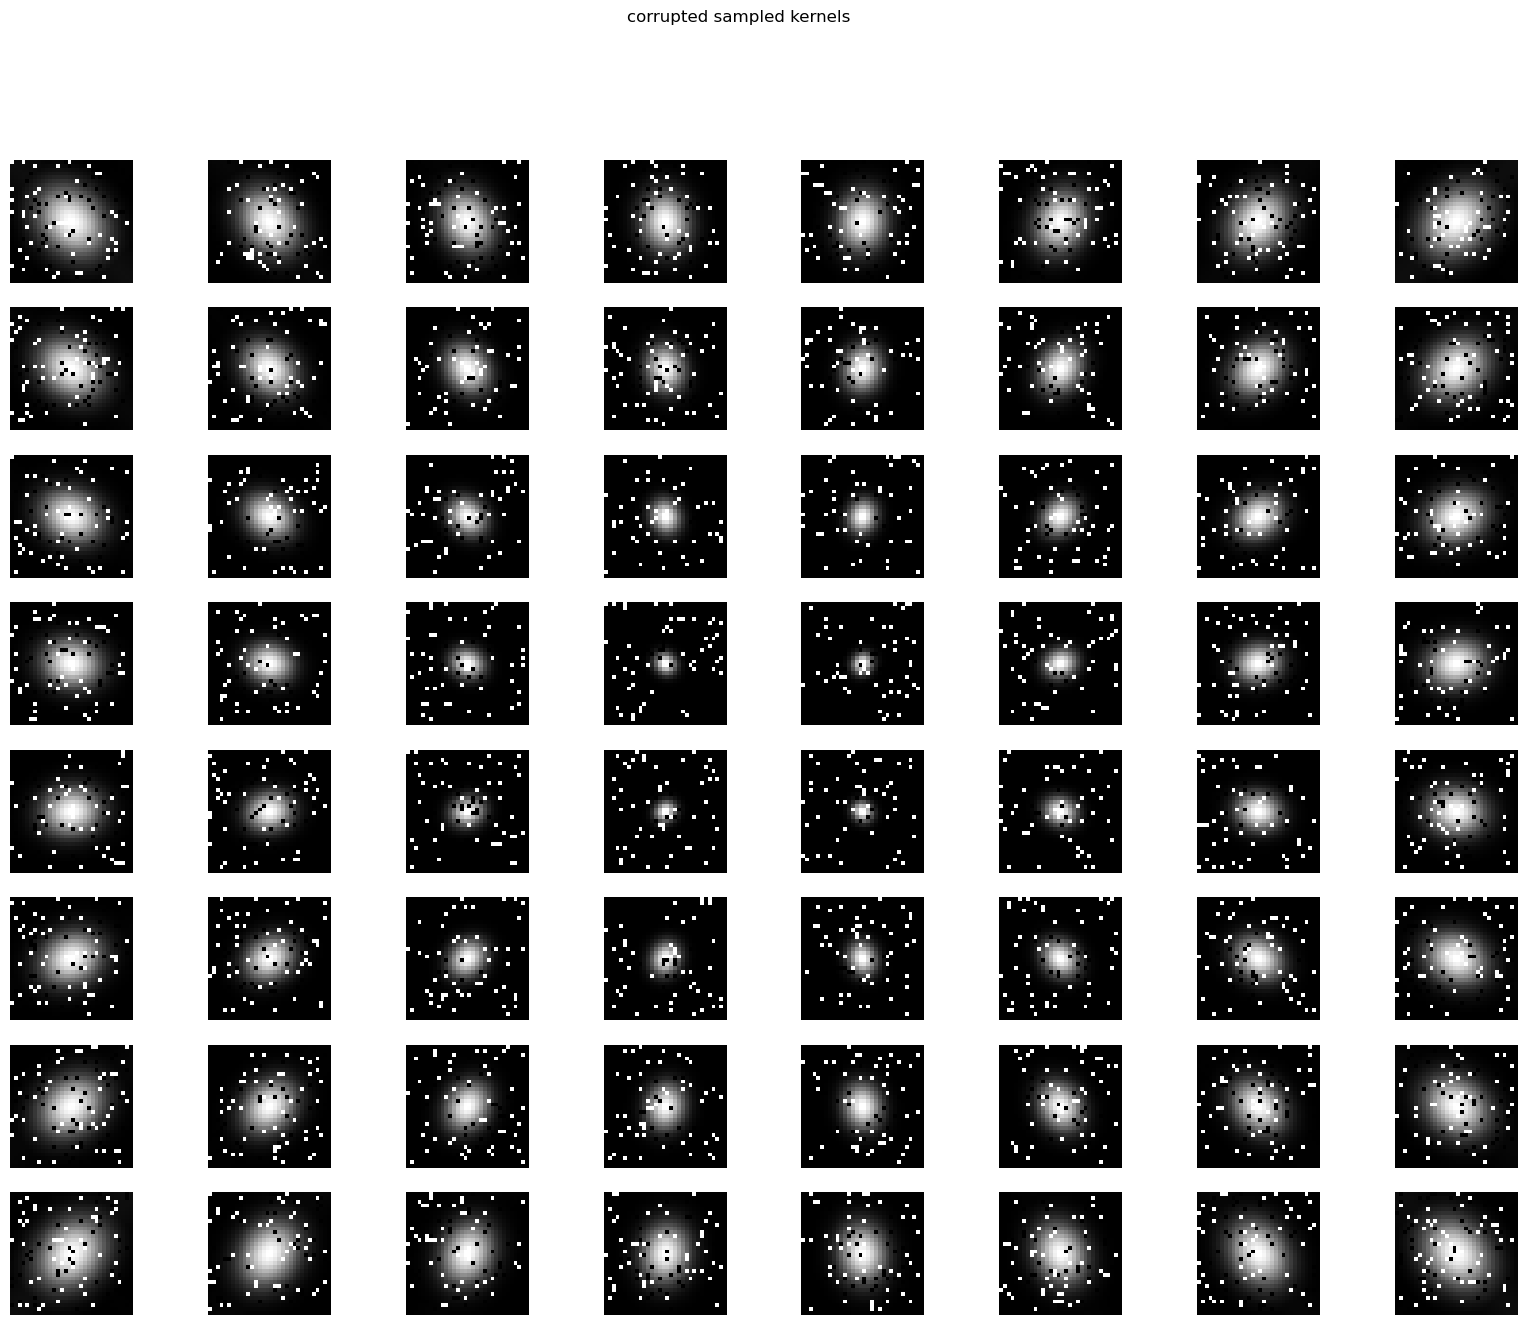

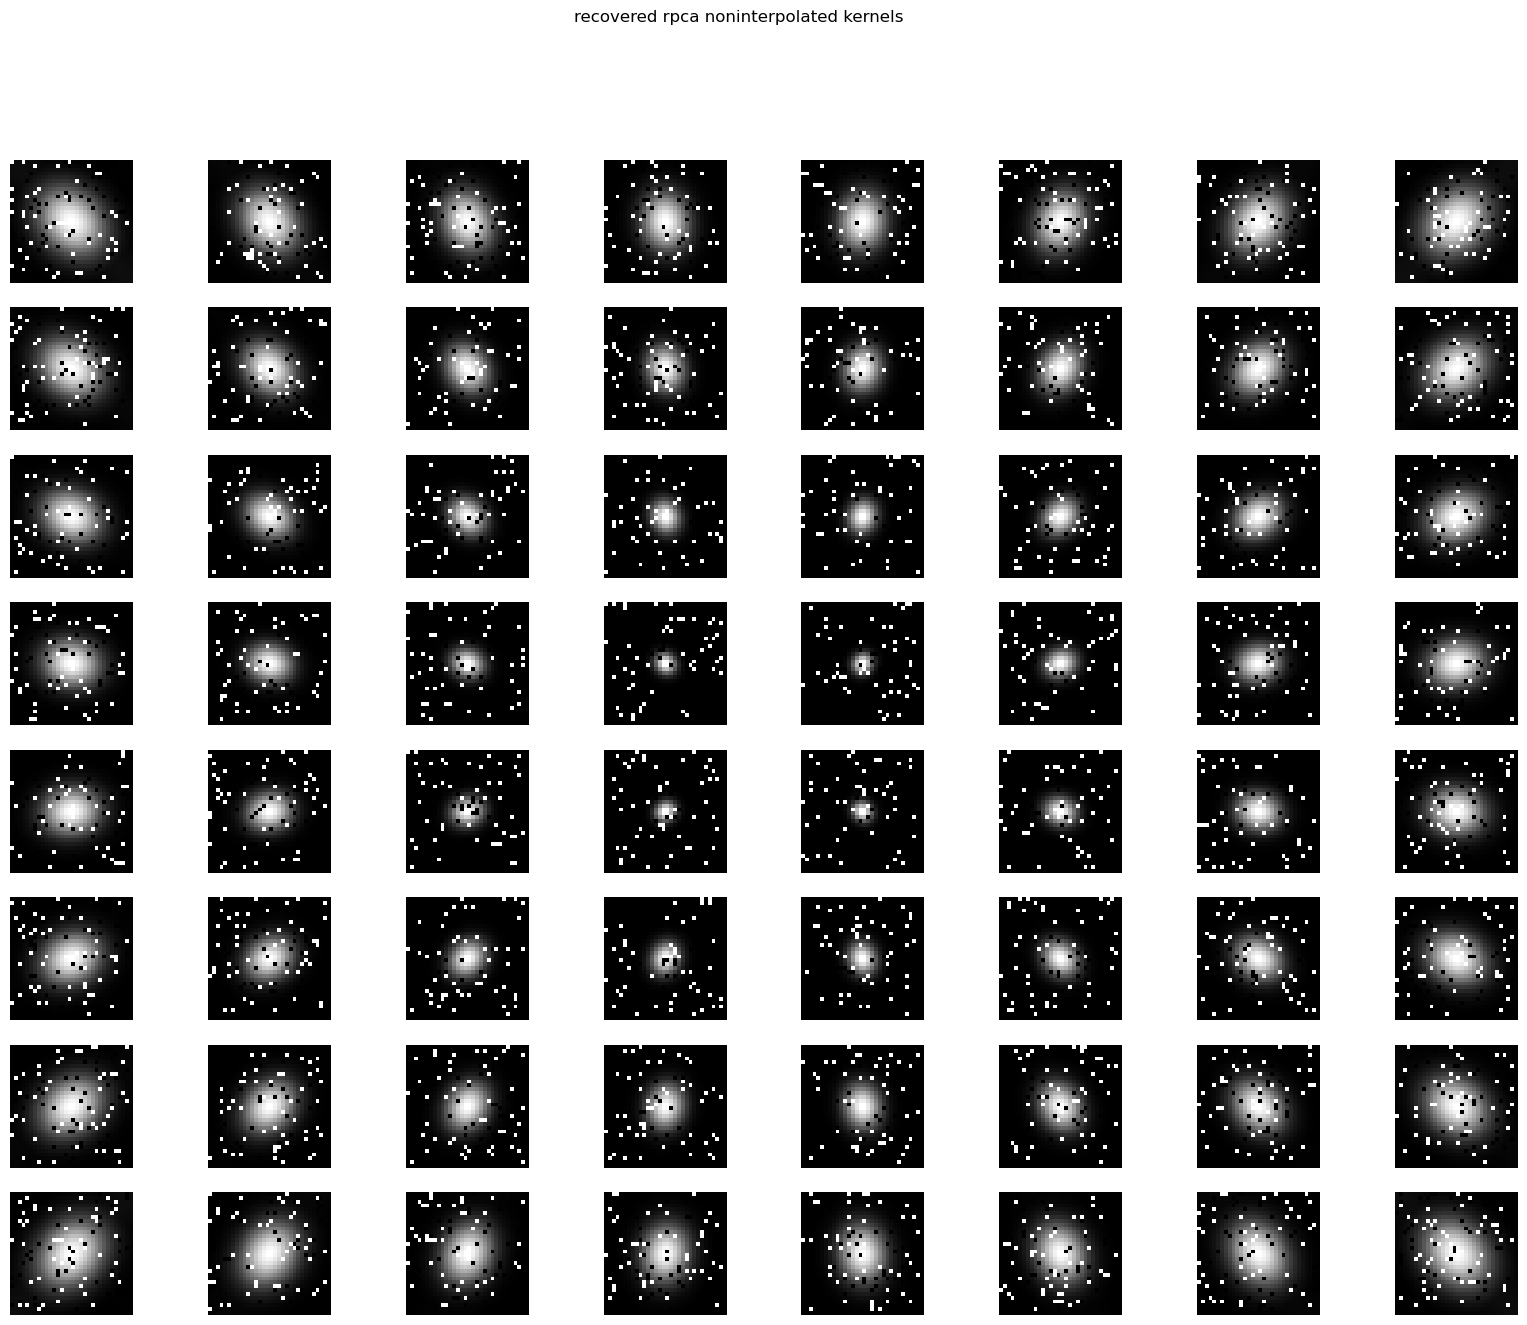

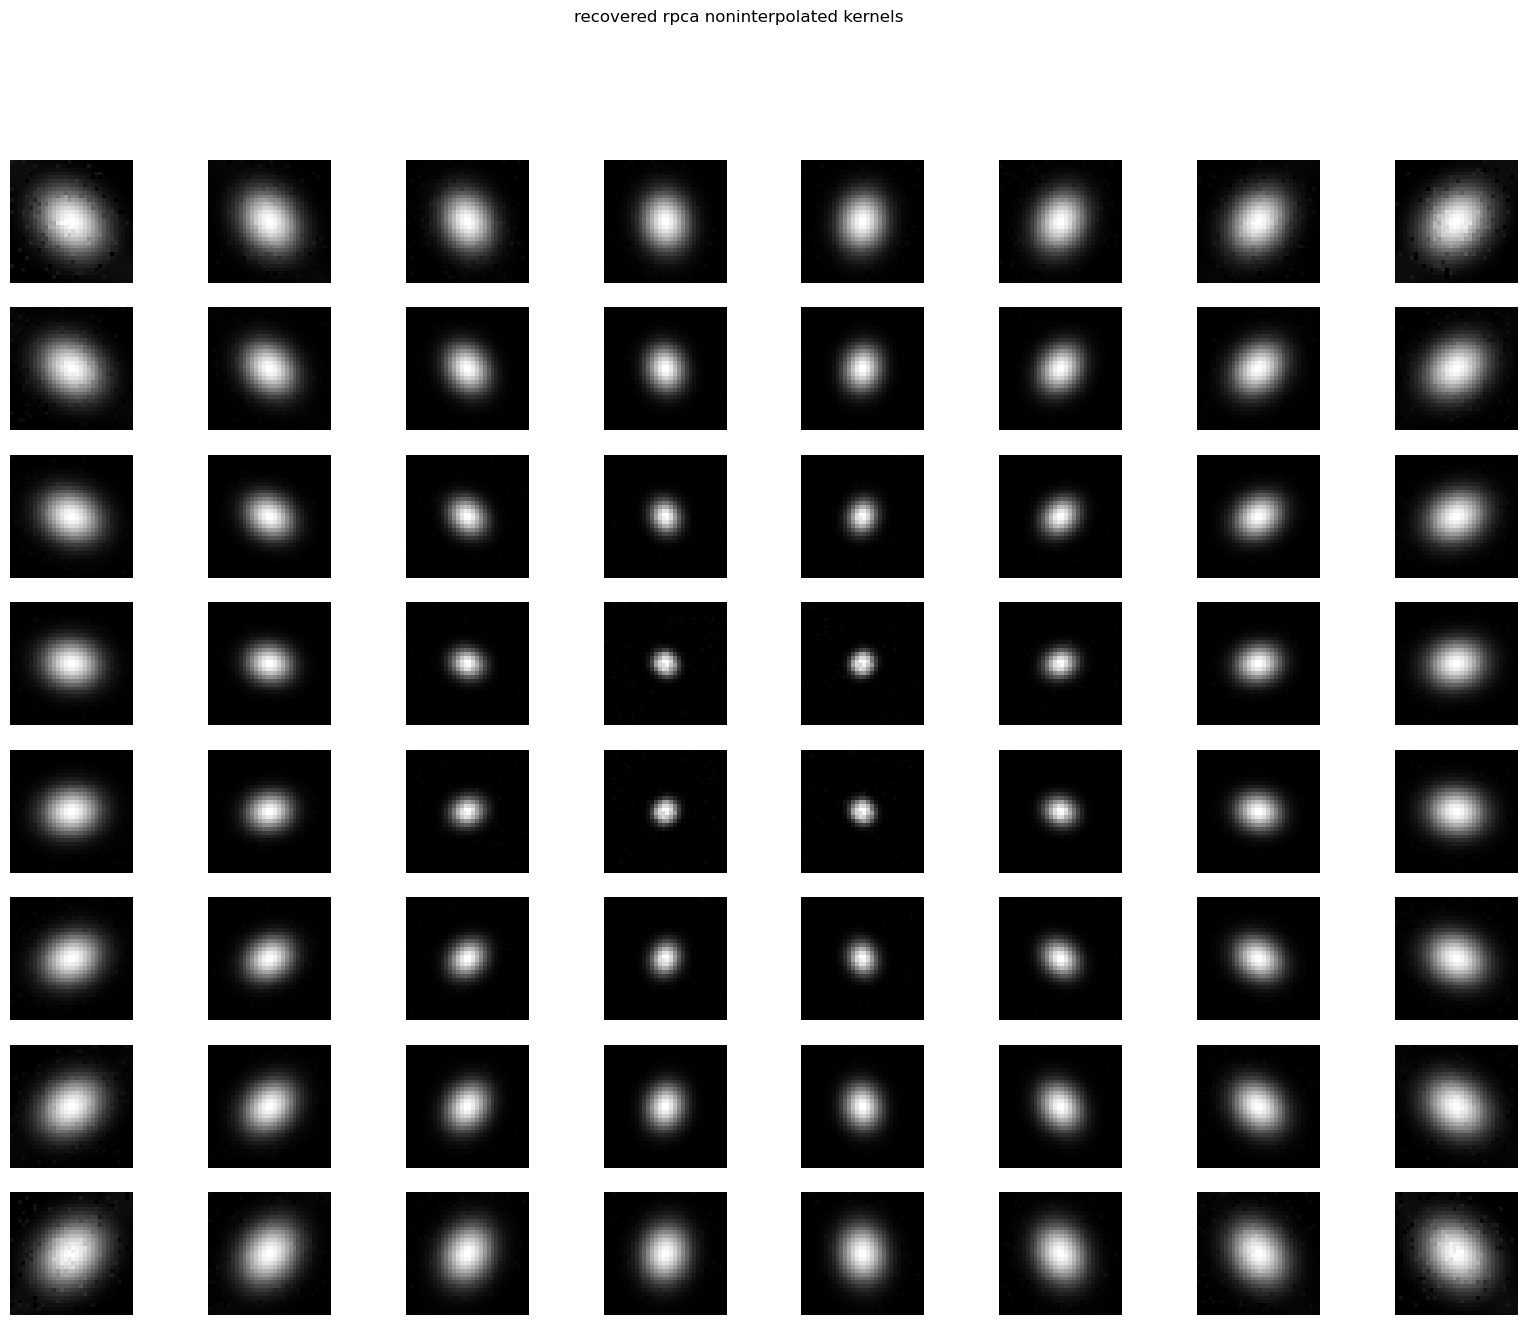

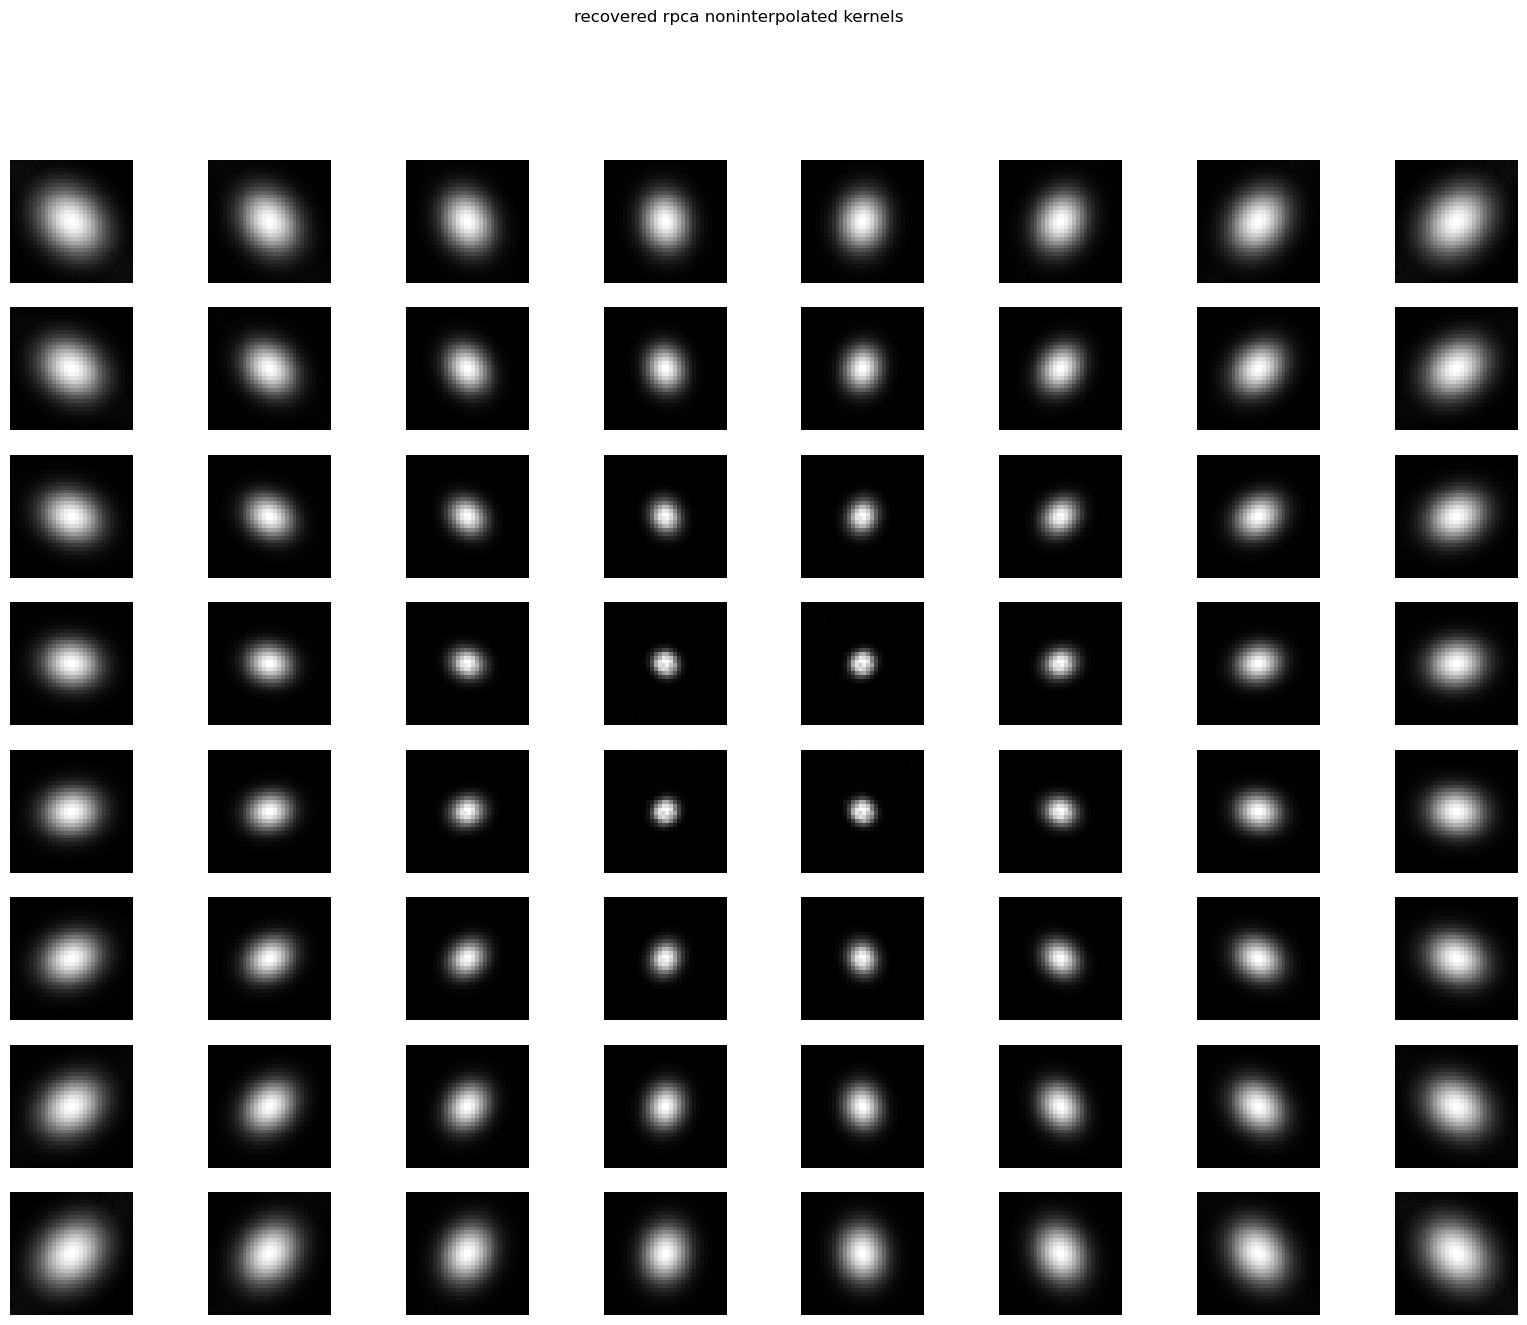

In [7]:
# decompose sampled lattice
r=64
pars_pca={'r':r}
pars_rpca={'lamb':0.09,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # 0.09 for 0.1 of amount
pars_wrpca={'lamb':wlamb,'r':r,'tol':1e-20,'max_iter':500,'debug':False} 
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
rpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca)
wrpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_wrpca)

r2=10
pars_pca2={'r':r2}
pars_rpca2={'lamb':0.09,'r':r2,'tol':1e-20,'max_iter':500,'debug':False} # 0.09 for 0.1 of amount
pars_wrpca2={'lamb':wlamb,'r':r2,'tol':1e-20,'max_iter':500,'debug':False} 
pca2_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca2)
rpca2_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca2)
wrpca2_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_wrpca2)



# plot corrupted sampled kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('corrupted sampled kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])(),cmap='gray')
plt.show()


# plot reconsctructed pca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

# plot reconsctructed rpca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

# plot reconsctructed rpca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(wrpca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

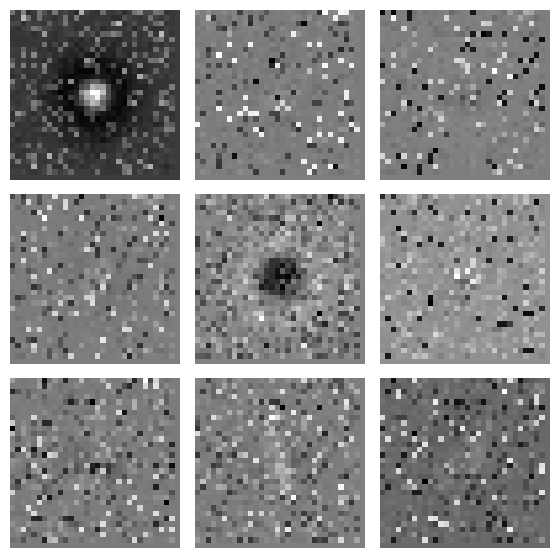

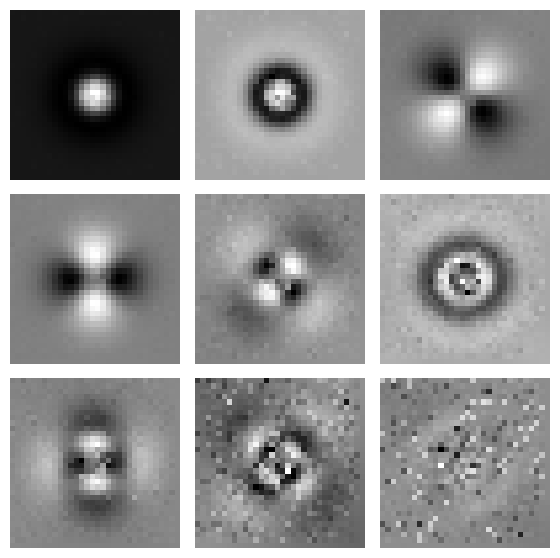

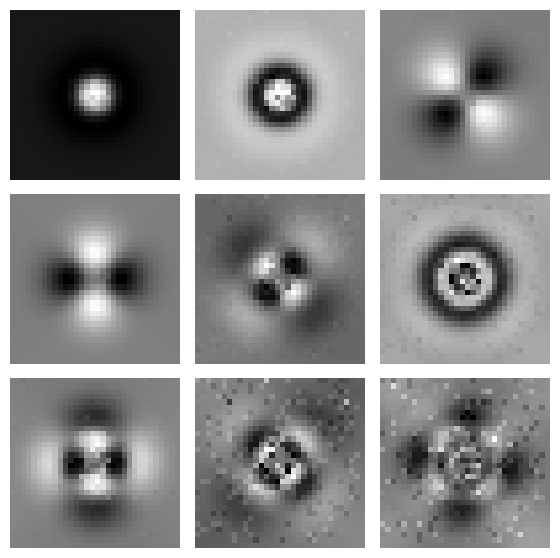

In [8]:
# plot pca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
# fig.suptitle('pca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(1+i*n_rows+j)](),cmap='gray')
plt.tight_layout()
plt.savefig('res0_pca_9eigenkernels.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# plot rpca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
# fig.suptitle('rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.eigenkernels[int(1+i*n_rows+j)](),cmap='gray')
plt.tight_layout()
plt.savefig('res0_rpca_9eigenkernels.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# plot wrpca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
# fig.suptitle('rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(wrpca_lat.eigenkernels[int(1+i*n_rows+j)](),cmap='gray')
plt.tight_layout()
plt.savefig('res0_wrpca_9eigenkernels.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

### scree plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


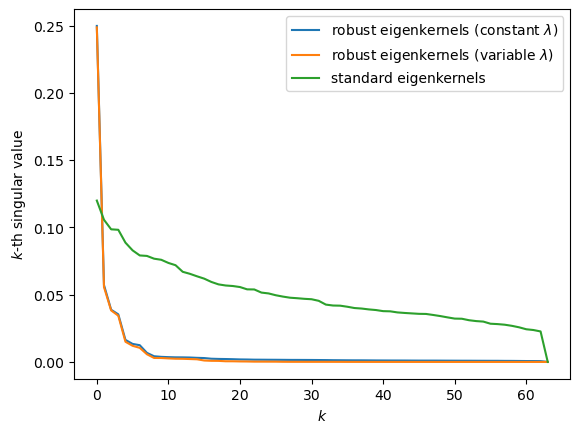

In [94]:
plt.plot(rpca_lat.singularvalues[1:],label=r'robust eigenkernels (constant $\lambda$)')
plt.plot(wrpca_lat.singularvalues[1:],label=r'robust eigenkernels (variable $\lambda$)')
plt.plot(pca_lat.singularvalues[1:],label='standard eigenkernels')
plt.ylabel(r'$k$-th singular value')
plt.xlabel(r'$k$')
plt.legend();
plt.savefig('res0_singular_values_w.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


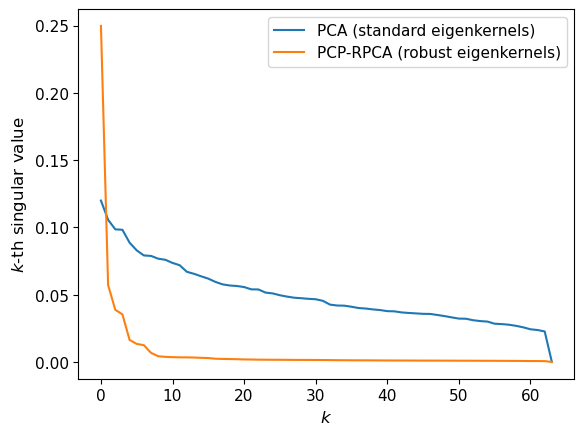

In [109]:
plt.plot(pca_lat.singularvalues[1:],label='PCA (standard eigenkernels)')
plt.plot(rpca_lat.singularvalues[1:],label=r'PCP-RPCA (robust eigenkernels)')
plt.ylabel(r'$k$-th singular value',fontsize=12)
plt.xlabel(r'$k$',fontsize=12)
plt.legend(fontsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.savefig('res0_singular_values.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

In [9]:
# max(kernel_shape8*8)

In [10]:
1/math.sqrt(kernel_shape[0]*kernel_shape[1])

0.03125

In [11]:
# plt.imshow(sampled_lat.kernel((0,0))())

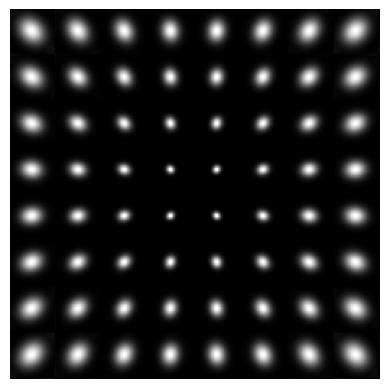

In [12]:
plt.imshow(lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_h.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

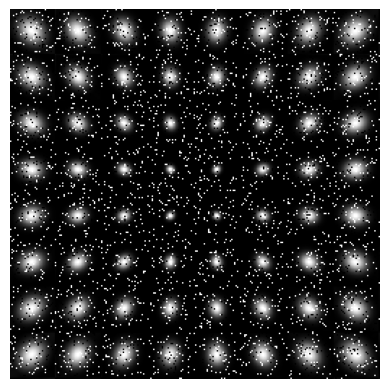

In [13]:
resampled_lat=sampled_lat.sample(sampled_shape,normalize=True,normalize_mode='minmax')
view_sampled_lat=blurtool.InterpolateLattice(resampled_lat,img_shape,mode='zero_dummy')
plt.imshow(view_sampled_lat.grid(sampled_shape,blur=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hplusnoise.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

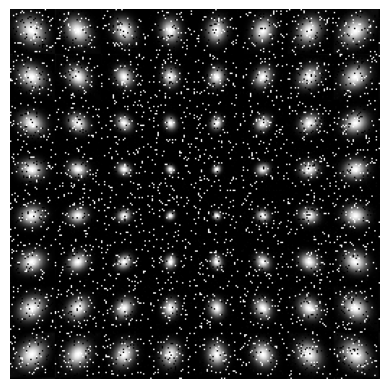

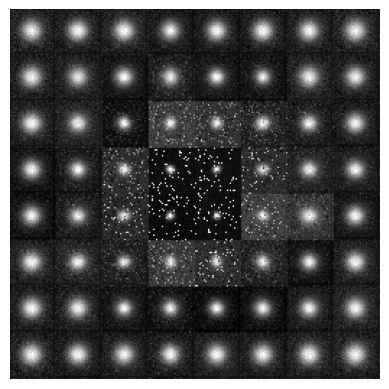

In [14]:
plt.imshow(pca_lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(pca2_lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_pca2.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

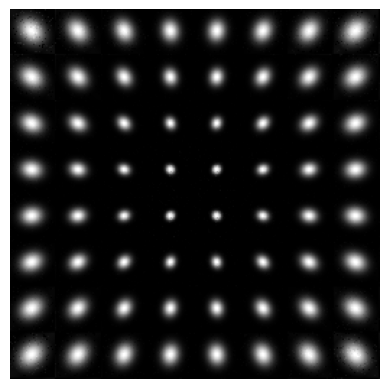

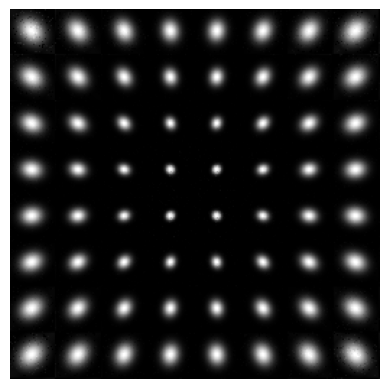

In [15]:
plt.imshow(rpca_lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_rpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(rpca_lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_rpca2.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

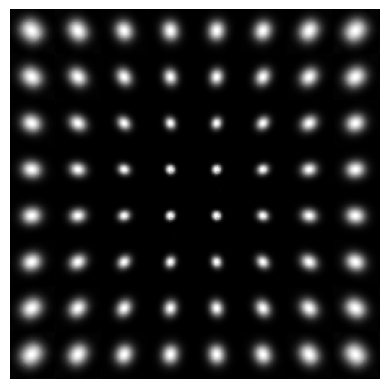

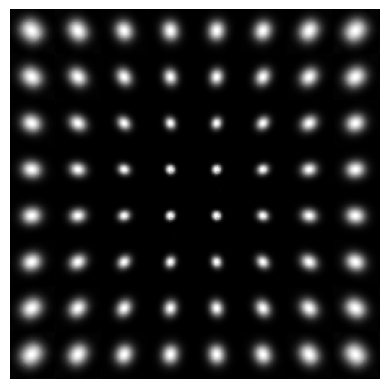

In [16]:
plt.imshow(wrpca_lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_wrpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(wrpca_lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_wrpca2.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

In [127]:
# mean PSNR and SSIM

psnr_pca=[]
psnr_rpca=[]
psnr_wrpca=[]
ssim_pca=[]
ssim_rpca=[]
ssim_wrpca=[]

psnr_pca2=[]
psnr_rpca2=[]
psnr_wrpca2=[]
ssim_pca2=[]
ssim_rpca2=[]
ssim_wrpca2=[]


resampled_lat=lat.sample(sampled_shape)

for key in sampled_lat.kernels:
    psnr_pca.append(blurtool.psnr(resampled_lat.kernel(key)(),pca_lat.noninterpolated_kernel(key)()).item())
    psnr_rpca.append(blurtool.psnr(resampled_lat.kernel(key)(),rpca_lat.noninterpolated_kernel(key)()).item())    
    psnr_wrpca.append(blurtool.psnr(resampled_lat.kernel(key)(),wrpca_lat.noninterpolated_kernel(key)()).item())
    ssim_pca.append(blurtool.ssim(resampled_lat.kernel(key)(),pca_lat.noninterpolated_kernel(key)()).item())
    ssim_rpca.append(blurtool.ssim(resampled_lat.kernel(key)(),rpca_lat.noninterpolated_kernel(key)()).item())
    ssim_wrpca.append(blurtool.ssim(resampled_lat.kernel(key)(),wrpca_lat.noninterpolated_kernel(key)()).item())
        
    psnr_pca2.append(blurtool.psnr(resampled_lat.kernel(key)(),pca2_lat.noninterpolated_kernel(key)()).item())
    psnr_rpca2.append(blurtool.psnr(resampled_lat.kernel(key)(),rpca2_lat.noninterpolated_kernel(key)()).item())    
    psnr_wrpca2.append(blurtool.psnr(resampled_lat.kernel(key)(),wrpca2_lat.noninterpolated_kernel(key)()).item())
    ssim_pca2.append(blurtool.ssim(resampled_lat.kernel(key)(),pca2_lat.noninterpolated_kernel(key)()).item())
    ssim_rpca2.append(blurtool.ssim(resampled_lat.kernel(key)(),rpca2_lat.noninterpolated_kernel(key)()).item())
    ssim_wrpca2.append(blurtool.ssim(resampled_lat.kernel(key)(),wrpca2_lat.noninterpolated_kernel(key)()).item())
    
print('-----------------------------')
print('mean PSNR(psf,psf_pca)=',sum(psnr_pca)/len(psnr_pca))
print('mean SSIM(psf,psf_pca)=',sum(ssim_pca)/len(ssim_pca))
print('-----------------------------')
print('mean PSNR(psf,psf_rpca)=',sum(psnr_rpca)/len(psnr_rpca))
print('mean SSIM(psf,psf_rpca)=',sum(ssim_rpca)/len(ssim_rpca))
print('-----------------------------')
print('mean PSNR(psf,psf_wrpca)=',sum(psnr_wrpca)/len(psnr_wrpca))
print('mean SSIM(psf,psf_wrpca)=',sum(ssim_wrpca)/len(ssim_wrpca))
print('-----------------------------')
print('mean PSNR(psf,psf_pca2)=',sum(psnr_pca2)/len(psnr_pca2))
print('mean SSIM(psf,psf_pca2)=',sum(ssim_pca2)/len(ssim_pca2))
print('-----------------------------')
print('mean PSNR(psf,psf_rpca2)=',sum(psnr_rpca2)/len(psnr_rpca2))
print('mean SSIM(psf,psf_rpca2)=',sum(ssim_rpca2)/len(ssim_rpca2))
print('-----------------------------')
print('mean PSNR(psf,psf_wrpca2)=',sum(psnr_wrpca2)/len(psnr_wrpca2))
print('mean SSIM(psf,psf_wrpca2)=',sum(ssim_wrpca2)/len(ssim_wrpca2))

-----------------------------
mean PSNR(psf,psf_pca)= 13.799165499224872
mean SSIM(psf,psf_pca)= 0.996598553789729
-----------------------------
mean PSNR(psf,psf_rpca)= 46.301503446526596
mean SSIM(psf,psf_rpca)= 0.9999608271723748
-----------------------------
mean PSNR(psf,psf_wrpca)= 55.38496256320339
mean SSIM(psf,psf_wrpca)= 0.9999523095919239
-----------------------------
mean PSNR(psf,psf_pca2)= 18.116133057701482
mean SSIM(psf,psf_pca2)= 0.9969872210001975
-----------------------------
mean PSNR(psf,psf_rpca2)= 44.67312701990647
mean SSIM(psf,psf_rpca2)= 0.9999609032493333
-----------------------------
mean PSNR(psf,psf_wrpca2)= 46.89117185228877
mean SSIM(psf,psf_wrpca2)= 0.9999521114890001


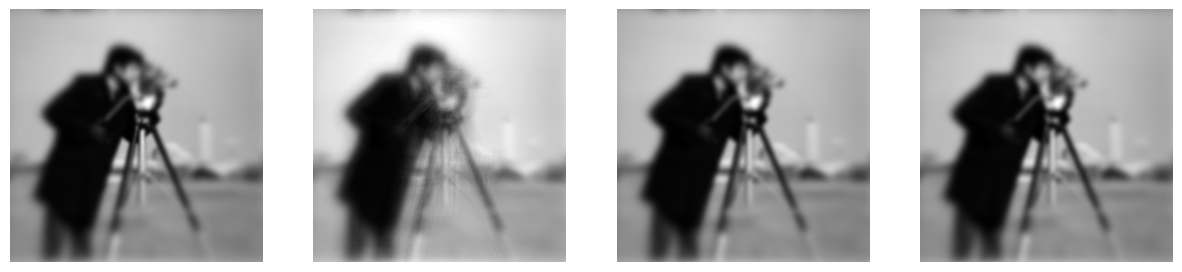

blur.forward_timer= 103.92666629899759
pca_blur.forward_timer= 0.16073971701553091
rpca_blur.forward_timer= 0.14950991998193786
wrpca_blur.forward_timer= 0.15151300298748538
PSNR(blurred,pca_blurred)= tensor(17.9793, dtype=torch.float64)
PSNR(blurred,rpca_blurred)= tensor(37.6018, dtype=torch.float64)
PSNR(blurred,wrpca_blurred)= tensor(38.7840, dtype=torch.float64)
SSIM(blurred,pca_blurred)= tensor(0.9407, dtype=torch.float64)
SSIM(blurred,rpca_blurred)= tensor(0.9980, dtype=torch.float64)
SSIM(blurred,wrpca_blurred)= tensor(0.9979, dtype=torch.float64)


In [32]:
## blur a test image 

# define blurs and apply
# blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
rpca_blur=blurtool.NonstationaryBlur(rpca_lat)
wrpca_blur=blurtool.NonstationaryBlur(wrpca_lat)

# blurred_test_image=blur.forward(test_image,n_pool=8,debug=True)
pca_blurred_test_image=pca_blur.forward(test_image,debug=False)
rpca_blurred_test_image=rpca_blur.forward(test_image,debug=False)
wrpca_blurred_test_image=wrpca_blur.forward(test_image,debug=False)


fig,ax=plt.subplots(1,4,figsize=(15,15))

# ax[0].axis('off')
# ax[0].imshow(test_image,cmap='gray')
ax[0].axis('off')
ax[0].imshow(blurred_test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(pca_blurred_test_image,cmap='gray')
ax[2].axis('off')
ax[2].imshow(rpca_blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(wrpca_blurred_test_image,cmap='gray')
plt.show()

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur.forward_timer)
print('wrpca_blur.forward_timer=',wrpca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image))
print('PSNR(blurred,rpca_blurred)=',blurtool.psnr(blurred_test_image,rpca_blurred_test_image))
print('PSNR(blurred,wrpca_blurred)=',blurtool.psnr(blurred_test_image,wrpca_blurred_test_image))

print('SSIM(blurred,pca_blurred)=',blurtool.ssim(blurred_test_image,pca_blurred_test_image))
print('SSIM(blurred,rpca_blurred)=',blurtool.ssim(blurred_test_image,rpca_blurred_test_image))
print('SSIM(blurred,wrpca_blurred)=',blurtool.ssim(blurred_test_image,wrpca_blurred_test_image))


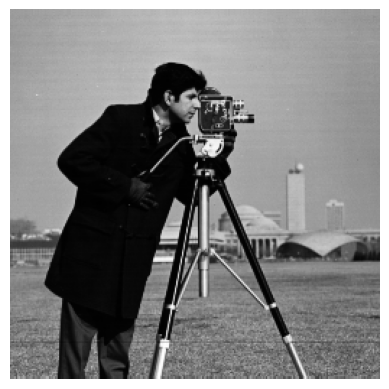

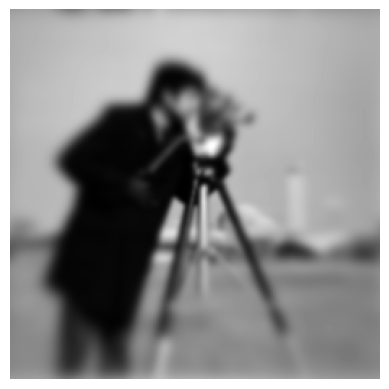

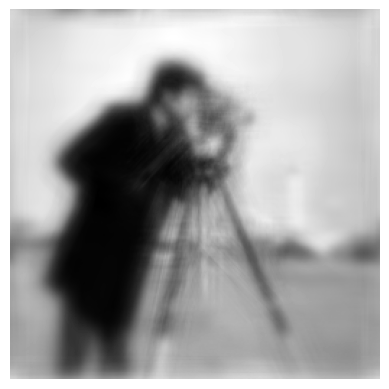

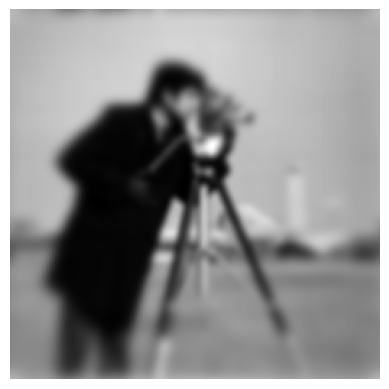

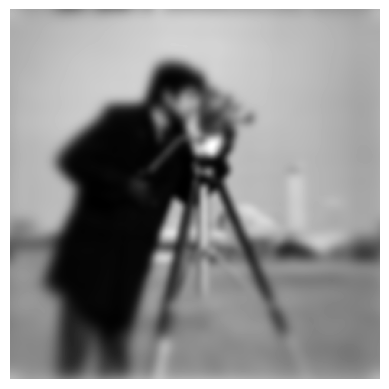

In [13]:
# save images
plt.imshow(test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_y.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(pca_blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_ypca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(rpca_blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_yrpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(wrpca_blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_ywrpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

kernel_shape= (32, 32)


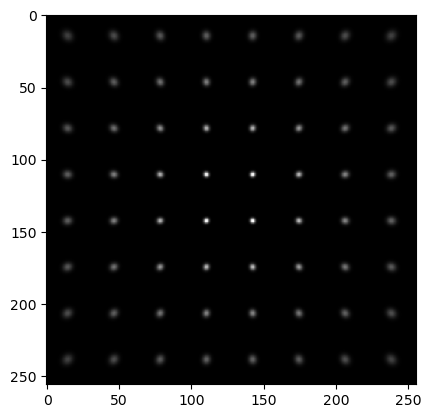

In [33]:

img_shape=(256,256)

# define lattice
kernel_shape=(32,32)
lattice_pars={'ax':0.06,'ay':0.06,'bx':0.13,'by':0.1,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)


r=64
pars_pca={'r':r}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
blur_pca=blurtool.NonstationaryBlur(pca_lat)

blurred_test_image=blur_pca.forward(test_image)

plt.imshow(pca_lat.grid(sampled_shape,blur=True),cmap='gray')

In [ ]:
deblur_pars={'niter':300,'mu':0.05,'lamb':0.01} # ={'niter':40,'mu':1,'lamb':0.0001} is ok, but with low psnr
deblur_pca=blurtool.TVGDDeblur(blur_pca,deblur_pars)

test_image_hat=deblur_pca(blurred_test_image,x_true=test_image)

iter:  0 	 PSNR= 21.924136382171287
iter:  1 	 PSNR= 22.00914617489717
iter:  2 	 PSNR= 22.076788417585757
iter:  3 	 PSNR= 22.137890284399372
iter:  4 	 PSNR= 22.193659497694874
iter:  5 	 PSNR= 22.24719880438412
iter:  6 	 PSNR= 22.29866279156557
iter:  7 	 PSNR= 22.348194788397922
iter:  8 	 PSNR= 22.394357171777706
iter:  9 	 PSNR= 22.43621897148431
iter:  10 	 PSNR= 22.47415850960857
iter:  11 	 PSNR= 22.505708425880147
iter:  12 	 PSNR= 22.535813766529998
iter:  13 	 PSNR= 22.564589999364728
iter:  14 	 PSNR= 22.592141364588937
iter:  15 	 PSNR= 22.617026169481882
iter:  16 	 PSNR= 22.623208890091426
iter:  17 	 PSNR= 22.628941620761964
iter:  18 	 PSNR= 22.6343643243802
iter:  19 	 PSNR= 22.639597947540913
iter:  20 	 PSNR= 22.64474652433706
iter:  21 	 PSNR= 22.64989909454105
iter:  22 	 PSNR= 22.65513125501915
iter:  23 	 PSNR= 22.66050576010182
iter:  24 	 PSNR= 22.66607194466923
iter:  25 	 PSNR= 22.671863276532115
iter:  26 	 PSNR= 22.677898171061557
iter:  27 	 PSNR= 22.68

iter:  221 	 PSNR= 21.902117457334775
iter:  222 	 PSNR= 21.89709658648423
iter:  223 	 PSNR= 21.892068287078807
iter:  224 	 PSNR= 21.887032819205537


In [ ]:
fig,ax=plt.subplots(1,3,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat,cmap='gray')
ax[2].axis('off')
plt.show()

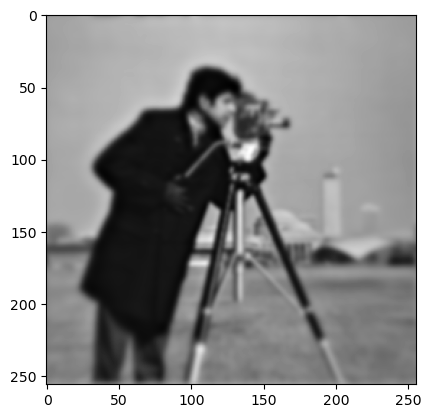

In [100]:
plt.imshow(test_image_hat,cmap='gray')

In [28]:
x = torch.tensor([-1 + 1j, -2 + 2j, 3 - 3j])
x=x.unsqueeze(0)
print(x)
torch.conj(x)

tensor([[-1.+1.j, -2.+2.j,  3.-3.j]])


tensor([[-1.-1.j, -2.-2.j,  3.+3.j]])

In [108]:
import numpy as np
np.conjugate(np.array([[1,2,3],[4,5,6]]))

array([[1, 2, 3],
       [4, 5, 6]])